#  African Credit Scoring Challenge — Zindi

**Objectif :** Prédire la probabilité de défaut de remboursement d'un prêt (`Target = 1`) basé sur les données financières des clients africains.  
**Métrique d'évaluation :** F1-Score  
**Structure :** Ce notebook suit les 6 étapes du ML Project Lifecycle (Problem Framing → Deployment)

---

## ⚙️ Setup — Imports & Configuration

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', 100)
print('✅ Setup done')

✅ Setup done


---
## 📌 ÉTAPE 1 — Problem Framing

### Contexte
Un gestionnaire d'actifs privé opérant dans plusieurs marchés financiers africains souhaite évaluer le **risque de crédit** de ses emprunteurs.  

### Formulation du problème
- **Objectif (business) :** Réduire les pertes financières liées aux prêts à haut risque en identifiant les emprunteurs susceptibles de faire défaut.
- **Objectif (ML) :** Classification binaire supervisée — prédire `Target ∈ {0, 1}` où `1 = défaut de remboursement`.
- **Métrique de succès :** F1-Score (adapté aux classes déséquilibrées, équilibre précision/rappel).
- **Inputs :** Données financières du prêt (montant, durée, pays, dates, type...)
- **Output :** Probabilité de défaut → classe binaire
- **Baseline non-ML :** Prédire toujours la classe majoritaire (0) → F1 ≈ 0 sur la classe 1 → inutile.
- **Défi principal :** Données fortement déséquilibrées (~98.2% non-défaut, ~1.8% défaut).
- **Généralisation :** Le modèle doit généraliser à des régions absentes du train (ex: Ghana uniquement dans le test).

---
## 📥 ÉTAPE 2 — Data Collection

### Contexte
Les données sont fournies directement par Zindi. On charge les fichiers `Train.csv`, `Test.csv` et `SampleSubmission.csv`.  
On effectue ensuite une première vérification de la qualité : taille, types, valeurs manquantes, représentativité train/test.  
Attention au **data leakage** : on ne doit jamais utiliser d'informations du test dans le preprocessing du train.

> ⚠️ Téléchargez les données depuis [Zindi](https://zindi.africa/competitions/african-credit-scoring-challenge/data) et placez-les dans le même répertoire que ce notebook.

In [4]:
# Charger les données
train = pd.read_csv('Train.csv')
test  = pd.read_csv('Test.csv')
ss    = pd.read_csv('SampleSubmission.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
print(f'\nTrain columns: {list(train.columns)}')

Train shape: (68654, 16)
Test shape:  (18594, 15)

Train columns: ['ID', 'customer_id', 'country_id', 'tbl_loan_id', 'lender_id', 'loan_type', 'Total_Amount', 'Total_Amount_to_Repay', 'disbursement_date', 'due_date', 'duration', 'New_versus_Repeat', 'Amount_Funded_By_Lender', 'Lender_portion_Funded', 'Lender_portion_to_be_repaid', 'target']


In [5]:
# Aperçu des premières lignes
train.head()

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0


In [6]:
# Types et valeurs manquantes
print('=== Train Info ===')
train.info()
print('\n=== Valeurs manquantes ===')
print(train.isnull().sum())

=== Train Info ===
<class 'pandas.DataFrame'>
RangeIndex: 68654 entries, 0 to 68653
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           68654 non-null  str    
 1   customer_id                  68654 non-null  int64  
 2   country_id                   68654 non-null  str    
 3   tbl_loan_id                  68654 non-null  int64  
 4   lender_id                    68654 non-null  int64  
 5   loan_type                    68654 non-null  str    
 6   Total_Amount                 68654 non-null  float64
 7   Total_Amount_to_Repay        68654 non-null  float64
 8   disbursement_date            68654 non-null  str    
 9   due_date                     68654 non-null  str    
 10  duration                     68654 non-null  int64  
 11  New_versus_Repeat            68654 non-null  str    
 12  Amount_Funded_By_Lender      68654 non-null  float64
 13  Lender_p

=== Distribution de la variable cible ===
target
0    67396
1     1258
Name: count, dtype: int64

Taux de défaut : 1.83%


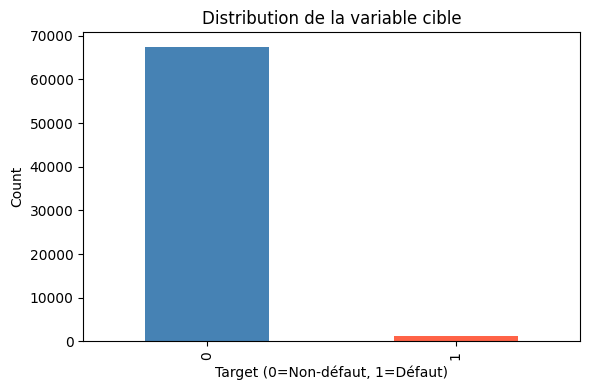

In [7]:
# Distribution de la cible
print('=== Distribution de la variable cible ===')
print(train['target'].value_counts())
print(f"\nTaux de défaut : {train['target'].mean()*100:.2f}%")

fig, ax = plt.subplots(figsize=(6, 4))
train['target'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_title('Distribution de la variable cible')
ax.set_xlabel('Target (0=Non-défaut, 1=Défaut)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [8]:
# Vérifier les pays train vs test (risque de distribution shift)
if 'country' in train.columns:
    print('Pays dans Train:', set(train['country'].unique()))
    print('Pays dans Test:', set(test['country'].unique()))
    new_in_test = set(test['country'].unique()) - set(train['country'].unique())
    print(f'Nouveaux pays uniquement dans le Test: {new_in_test}')

---
## 🔧 ÉTAPE 3 — Data Wrangling

### Contexte
Cette étape transforme les données brutes en un format utilisable par les modèles ML :  
- **Feature Engineering :** création de nouvelles variables à partir des dates, des ratios financiers, et des indicateurs économiques externes.
- **Encodage :** transformation des variables catégorielles (label encoding, one-hot).
- **Transformation :** normalisation logarithmique des variables skewed.
- **Pipeline :** on concatène train et test pour assurer la cohérence des transformations, puis on les sépare à nouveau.  

> 🔑 Règle anti-leakage : toute statistique (moyenne, écart-type) calculée sur les données groupées doit être calculée sur le train uniquement, puis appliquée au test.

In [9]:
# ---- Identification de la colonne cible ----
# Adapter si le nom de colonne diffère
TARGET_COL = 'target'  # ou 'Target' selon les données réelles
ID_COL     = 'ID'

# On sépare le label avant la concaténation
y = train[TARGET_COL].copy()
train_ids = train[ID_COL].copy()
test_ids  = test[ID_COL].copy()

train_df = train.drop(columns=[TARGET_COL, ID_COL])
test_df  = test.drop(columns=[ID_COL])

# Concaténation pour feature engineering homogène
n_train = len(train_df)
df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
print(f'Shape combiné: {df.shape}')

Shape combiné: (87248, 14)


In [10]:
# ---- Features temporelles ----
date_cols = [c for c in df.columns if 'date' in c.lower()]
print(f'Colonnes de dates détectées: {date_cols}')

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    df[f'{col}_year']    = df[col].dt.year
    df[f'{col}_month']   = df[col].dt.month
    df[f'{col}_day']     = df[col].dt.day
    df[f'{col}_dayofweek'] = df[col].dt.dayofweek
    # Encodage cyclique du mois
    df[f'{col}_month_sin'] = np.sin(2 * np.pi * df[col].dt.month / 12)
    df[f'{col}_month_cos'] = np.cos(2 * np.pi * df[col].dt.month / 12)

# Durée du prêt en jours si on a disbursement_date et due_date
if 'disbursement_date' in date_cols and 'due_date' in date_cols:
    df['loan_term_days'] = (df['due_date'] - df['disbursement_date']).dt.days

# Supprimer les colonnes dates originales
df = df.drop(columns=date_cols, errors='ignore')
print('✅ Features temporelles créées')

Colonnes de dates détectées: ['disbursement_date', 'due_date']
✅ Features temporelles créées


In [11]:
# ---- Features financières ----
# Adapter les noms de colonnes selon les données réelles
# Exemples de features financières typiques pour ce challenge :

# Ratio remboursement (total_amount_to_pay / loan_amount)
if 'total_amount' in df.columns and 'loan_amount' in df.columns:
    df['repayment_ratio'] = df['total_amount'] / (df['loan_amount'] + 1e-9)
    df['extra_charge']    = df['total_amount'] - df['loan_amount']

# Ratio montant/durée
if 'loan_amount' in df.columns and 'loan_term_days' in df.columns:
    df['amount_per_day'] = df['loan_amount'] / (df['loan_term_days'] + 1e-9)

# Terme d'interaction
if 'repayment_ratio' in df.columns and 'loan_term_days' in df.columns:
    df['repayment_x_duration'] = df['repayment_ratio'] * df['loan_term_days']

# Log-transformation des variables skewed
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].min() > 0:
        skew = df[col].skew()
        if abs(skew) > 1.5:
            df[f'log_{col}'] = np.log1p(df[col])

print('Features financières créées')

Features financières créées


In [12]:
# ---- Encodage des variables catégorielles ----
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Variables catégorielles: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

print(' Encodage effectué')

Variables catégorielles: ['country_id', 'loan_type', 'New_versus_Repeat']
 Encodage effectué


In [13]:
# ---- Agrégations par pays / type de prêt ----
# Re-séparer train/test temporairement pour calculer stats sur train seulement
df_train_fe = df.iloc[:n_train].copy()
df_train_fe['target'] = y.values

group_cols = [c for c in ['country', 'loan_type', 'region'] if c in df.columns]
for g in group_cols:
    if 'loan_amount' in df.columns:
        stats = df_train_fe.groupby(g)['loan_amount'].agg(['mean', 'std']).rename(
            columns={'mean': f'{g}_loan_mean', 'std': f'{g}_loan_std'})
        df = df.merge(stats, on=g, how='left')
        
    if 'repayment_ratio' in df.columns:
        r_stats = df_train_fe.groupby(g)['repayment_ratio'].agg(['mean']).rename(
            columns={'mean': f'{g}_repayment_mean'})
        df = df.merge(r_stats, on=g, how='left')

# Remplir les NaN introduits par les nouveaux pays dans le test
df = df.fillna(df.median(numeric_only=True))

print(f'Shape après feature engineering: {df.shape}')
print('✅ Data Wrangling terminé')

Shape après feature engineering: (87248, 32)
✅ Data Wrangling terminé


In [14]:
# ---- Re-séparation train/test ----
X_train = df.iloc[:n_train].copy()
X_test  = df.iloc[n_train:].copy()

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (68654, 32), X_test: (18594, 32)


---
## 🔍 ÉTAPE 4 — Data Analysis (EDA)

### Contexte
L'analyse exploratoire permet de comprendre les distributions, détecter les outliers, valider la cohérence des features créées, et prioriser les variables pour le modèle.  
Points clés à analyser :
- Distribution des features les plus importantes
- Corrélations avec la variable cible
- Identification des outliers
- Vérification de la représentativité train vs test

In [15]:
# Statistiques descriptives
X_train.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
customer_id,68654.000000,254390.256780,26642.719918,145.000000,248945.750000,255361.000000,262269.250000,312737.000000
country_id,68654.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
tbl_loan_id,68654.000000,263056.266248,39486.661487,101323.000000,233942.250000,260305.500000,286962.750000,375320.000000
lender_id,68654.000000,266420.528462,3590.999004,245684.000000,267278.000000,267278.000000,267278.000000,267278.000000
loan_type,68654.000000,1.815845,5.698450,0.000000,0.000000,0.000000,0.000000,23.000000
Total_Amount,68654.000000,14836.828617,141649.868388,2.000000,2295.000000,5249.000000,11450.000000,23000000.000000
Total_Amount_to_Repay,68654.000000,15639.929901,165078.352830,0.000000,2329.000000,5325.000000,11650.000000,25415000.000000
duration,68654.000000,8.544586,13.343145,1.000000,7.000000,7.000000,7.000000,1096.000000
New_versus_Repeat,68654.000000,0.991741,0.090503,0.000000,1.000000,1.000000,1.000000,1.000000
Amount_Funded_By_Lender,68654.000000,2545.663204,11922.724169,0.000000,234.000000,915.000000,2272.650000,1600000.000000


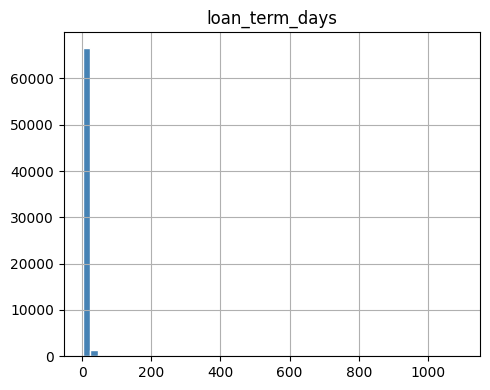

In [16]:
# Distribution des features numériques clés
key_features = [c for c in ['loan_amount', 'repayment_ratio', 'loan_term_days', 'total_amount']
                if c in X_train.columns][:4]

if key_features:
    fig, axes = plt.subplots(1, len(key_features), figsize=(5*len(key_features), 4))
    if len(key_features) == 1:
        axes = [axes]
    for ax, feat in zip(axes, key_features):
        X_train[feat].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(feat)
    plt.tight_layout()
    plt.show()
else:
    # Distribution générale
    X_train.select_dtypes(include=[np.number]).iloc[:, :4].hist(
        figsize=(16, 4), bins=40, color='steelblue', edgecolor='white')
    plt.tight_layout()
    plt.show()

Top 20 features les plus corrélées avec la cible:
log_loan_term_days             0.229718
log_duration                   0.229718
loan_type                      0.199498
duration                       0.189889
loan_term_days                 0.189889
log_lender_id                  0.166603
lender_id                      0.166202
log_due_date_year              0.143731
due_date_year                  0.143727
New_versus_Repeat              0.130334
log_disbursement_date_year     0.129515
disbursement_date_year         0.129514
disbursement_date_month_sin    0.117634
due_date_month_sin             0.115428
Lender_portion_to_be_repaid    0.109517
Amount_Funded_By_Lender        0.101845
Total_Amount_to_Repay          0.087089
Total_Amount                   0.086043
log_Total_Amount               0.074828
due_date_month                 0.074084
dtype: float64


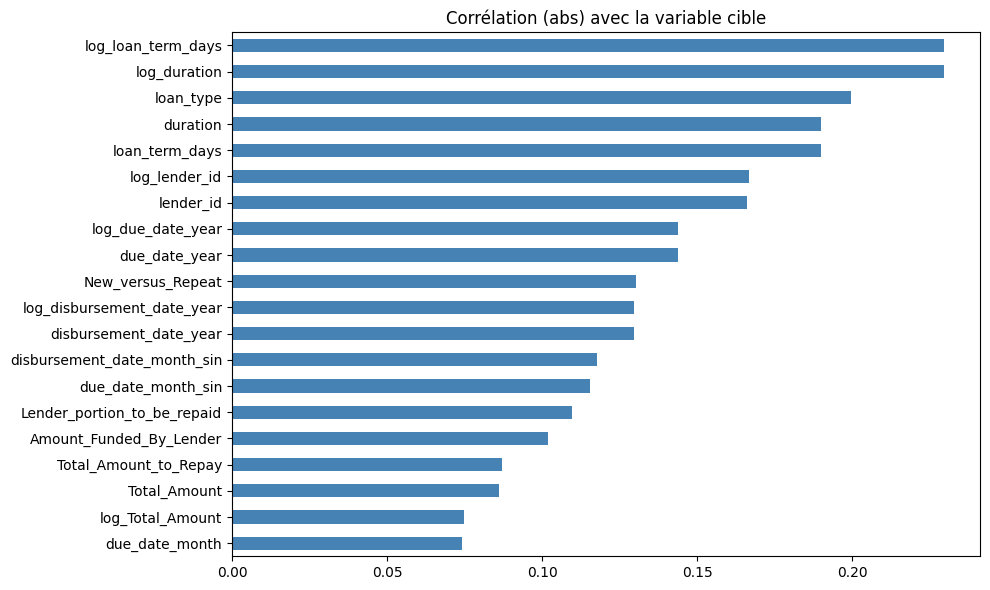

In [17]:
# Corrélation avec la cible
corr_with_target = X_train.corrwith(y).abs().sort_values(ascending=False)
print('Top 20 features les plus corrélées avec la cible:')
print(corr_with_target.head(20))

fig, ax = plt.subplots(figsize=(10, 6))
corr_with_target.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Corrélation (abs) avec la variable cible')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

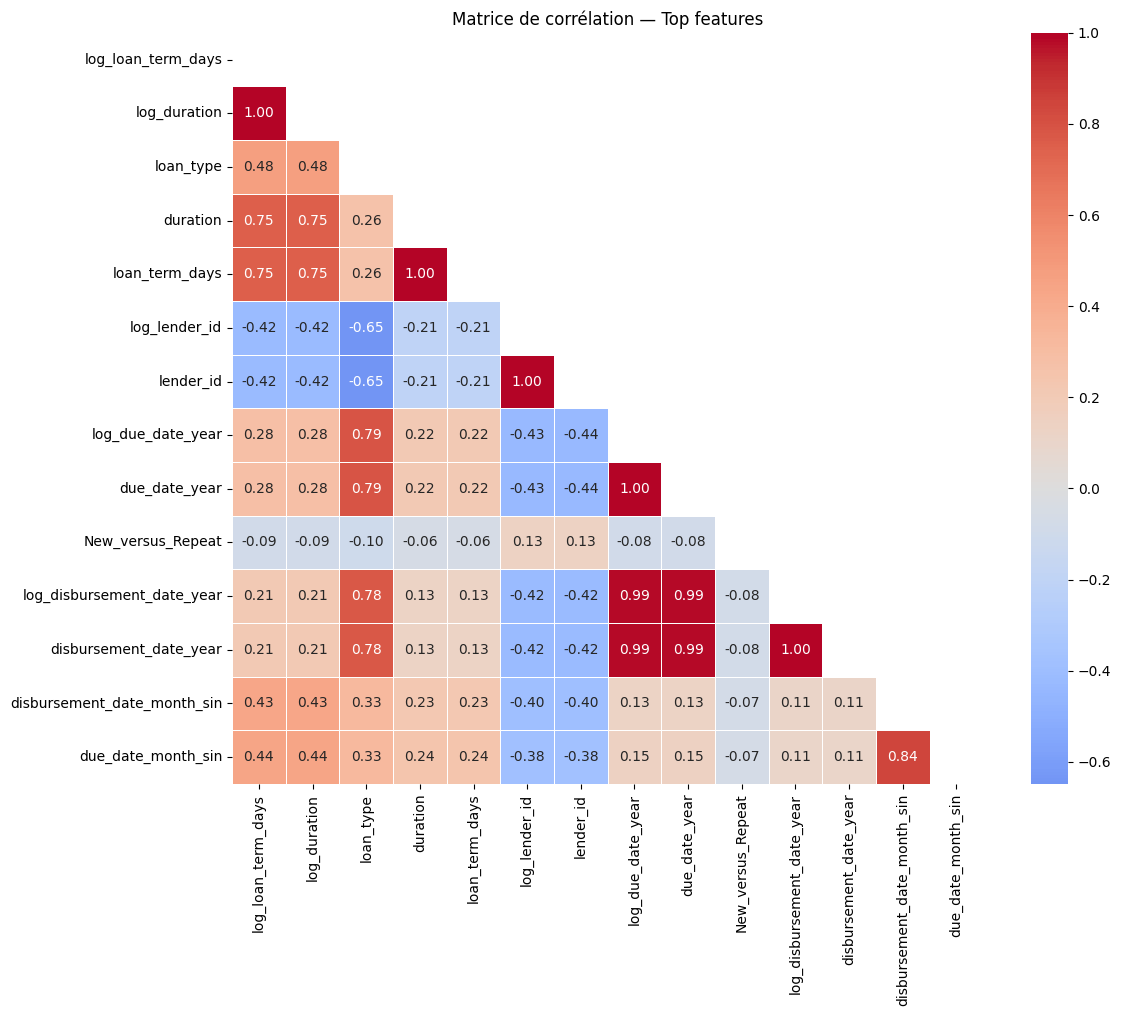

In [18]:
# Matrice de corrélation (top 15 features)
top_feats = corr_with_target.head(14).index.tolist()
corr_matrix = X_train[top_feats].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matrice de corrélation — Top features')
plt.tight_layout()
plt.show()

In [19]:
# Vérifier le déséquilibre de classes et définir scale_pos_weight pour XGBoost
neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos
print(f'Classe 0 (non-défaut): {neg} ({neg/len(y)*100:.1f}%)')
print(f'Classe 1 (défaut):     {pos} ({pos/len(y)*100:.1f}%)')
print(f'scale_pos_weight pour XGBoost: {scale_pos_weight:.1f}')

Classe 0 (non-défaut): 67396 (98.2%)
Classe 1 (défaut):     1258 (1.8%)
scale_pos_weight pour XGBoost: 53.6


---
## 🤖 ÉTAPE 5 — Model Training & Evaluation

### Contexte
Stratégie :
1. **Baselines :** Logistic Regression (modèle simple de référence)
2. **Modèles avancés :** XGBoost, LightGBM, CatBoost — les 3 meilleurs modèles pour données tabulaires
3. **Optimisation des hyperparamètres :** Optuna (Bayesian optimization) sur LightGBM
4. **Cross-validation :** StratifiedKFold (k=5) pour gérer le déséquilibre des classes
5. **Ensemble :** Stacking des prédictions des 3 modèles GBDT avec une Logistic Regression meta-model

**Gestion du déséquilibre :**
- `scale_pos_weight` (XGBoost/LightGBM) ou `class_weight='balanced'`
- Seuil de décision optimisé sur le F1-Score (pas forcément 0.5)

> ⚠️ Les hyperparamètres sont entraînés uniquement sur les folds de validation, jamais sur le test.

In [20]:
# ---- Configuration de la cross-validation ----
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

In [21]:
# ---- Fonction utilitaire : trouver le meilleur seuil de décision ----
def find_best_threshold(y_true, y_proba, metric=f1_score):
    """Cherche le seuil qui maximise le F1-Score."""
    thresholds = np.linspace(0.01, 0.99, 200)
    scores = [metric(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = np.argmax(scores)
    return thresholds[best_idx], scores[best_idx]


# ---- Fonction d'entraînement en OOF (Out-Of-Fold) ----
def train_oof(model, X, y, X_test, skf, model_name='Model'):
    """Entraîne un modèle en OOF et retourne les prédictions OOF + test."""
    oof_preds  = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    f1_scores  = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        
        val_proba = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = val_proba
        test_preds += model.predict_proba(X_test)[:, 1] / N_SPLITS
        
        best_thresh, f1 = find_best_threshold(y_val, val_proba)
        f1_scores.append(f1)
        print(f'  Fold {fold+1}/{N_SPLITS} — F1: {f1:.4f} (thresh={best_thresh:.2f})')
    
    mean_f1 = np.mean(f1_scores)
    print(f'\n📊 {model_name} — CV F1 moyen: {mean_f1:.4f} ± {np.std(f1_scores):.4f}\n')
    return oof_preds, test_preds, mean_f1

In [22]:
# ---- Baseline : Logistic Regression ----
print('=== Baseline : Logistic Regression ===')
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
oof_lr, test_lr, f1_lr = train_oof(lr, X_train, y, X_test, skf, 'Logistic Regression')

=== Baseline : Logistic Regression ===
  Fold 1/5 — F1: 0.5614 (thresh=0.84)
  Fold 2/5 — F1: 0.5288 (thresh=0.85)
  Fold 3/5 — F1: 0.5399 (thresh=0.87)
  Fold 4/5 — F1: 0.5291 (thresh=0.86)
  Fold 5/5 — F1: 0.5663 (thresh=0.86)

📊 Logistic Regression — CV F1 moyen: 0.5451 ± 0.0159



In [23]:
# ---- LightGBM ----
print('=== LightGBM ===')
lgbm = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
oof_lgbm, test_lgbm, f1_lgbm = train_oof(lgbm, X_train, y, X_test, skf, 'LightGBM')

=== LightGBM ===
  Fold 1/5 — F1: 0.7913 (thresh=0.79)
  Fold 2/5 — F1: 0.8423 (thresh=0.65)
  Fold 3/5 — F1: 0.8118 (thresh=0.65)
  Fold 4/5 — F1: 0.8134 (thresh=0.29)
  Fold 5/5 — F1: 0.8135 (thresh=0.22)

📊 LightGBM — CV F1 moyen: 0.8145 ± 0.0163



In [24]:
# ---- XGBoost ----
print('=== XGBoost ===')
xgbm = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)
oof_xgbm, test_xgbm, f1_xgbm = train_oof(xgbm, X_train, y, X_test, skf, 'XGBoost')

=== XGBoost ===
  Fold 1/5 — F1: 0.7863 (thresh=0.55)
  Fold 2/5 — F1: 0.8235 (thresh=0.58)
  Fold 3/5 — F1: 0.7975 (thresh=0.63)
  Fold 4/5 — F1: 0.8148 (thresh=0.72)
  Fold 5/5 — F1: 0.8108 (thresh=0.66)

📊 XGBoost — CV F1 moyen: 0.8066 ± 0.0132



In [25]:
# ---- CatBoost ----
print('=== CatBoost ===')
cat_cols_idx = []  # CatBoost peut gérer les catégorielles directement

catb = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    bagging_temperature=0.5,
    scale_pos_weight=scale_pos_weight,
    random_seed=SEED,
    verbose=0
)
oof_catb, test_catb, f1_catb = train_oof(catb, X_train, y, X_test, skf, 'CatBoost')

=== CatBoost ===
  Fold 1/5 — F1: 0.7609 (thresh=0.79)
  Fold 2/5 — F1: 0.7839 (thresh=0.87)
  Fold 3/5 — F1: 0.7806 (thresh=0.83)
  Fold 4/5 — F1: 0.7826 (thresh=0.77)
  Fold 5/5 — F1: 0.7859 (thresh=0.89)

📊 CatBoost — CV F1 moyen: 0.7788 ± 0.0091



In [26]:
# ---- Optimisation des hyperparamètres LightGBM avec Optuna ----
print('=== Optuna: Optimisation hyperparamètres LightGBM ===')

def lgbm_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 31, 255),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 100),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': scale_pos_weight,
        'random_state': SEED, 'verbose': -1, 'n_jobs': -1
    }
    model = lgb.LGBMClassifier(**params)
    f1s = []
    for train_idx, val_idx in skf.split(X_train, y):
        model.fit(X_train.iloc[train_idx], y.iloc[train_idx])
        proba = model.predict_proba(X_train.iloc[val_idx])[:, 1]
        _, f1 = find_best_threshold(y.iloc[val_idx], proba)
        f1s.append(f1)
    return np.mean(f1s)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

print(f'\nMeilleur F1 Optuna: {study.best_value:.4f}')
print(f'Meilleurs params: {study.best_params}')

=== Optuna: Optimisation hyperparamètres LightGBM ===


Best trial: 0. Best value: 0.795292:  10%|█         | 5/50 [07:33<1:08:00, 90.68s/it] 


[W 2026-02-17 22:39:54,060] Trial 5 failed with parameters: {'n_estimators': 1494, 'learning_rate': 0.020497980520950188, 'num_leaves': 148, 'max_depth': 7, 'min_child_samples': 26, 'subsample': 0.9847923138822793, 'colsample_bytree': 0.8875664116805573, 'reg_alpha': 5.727904470799623, 'reg_lambda': 3.7958531426706403} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/mirado/.local/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_35393/907590328.py", line 21, in lgbm_objective
    model.fit(X_train.iloc[train_idx], y.iloc[train_idx])
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mirado/.local/lib/python3.13/site-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
    ~~~~~~~~~~~^
        X,
        ^^
    ...<12 lines>...
        init_model=init_model,
        ^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home

KeyboardInterrupt: 

In [ ]:
# ---- LightGBM optimisé ----
print('=== LightGBM Optimisé ===')
best_params = study.best_params
best_params.update({'scale_pos_weight': scale_pos_weight, 'random_state': SEED,
                    'verbose': -1, 'n_jobs': -1})

lgbm_opt = lgb.LGBMClassifier(**best_params)
oof_lgbm_opt, test_lgbm_opt, f1_lgbm_opt = train_oof(
    lgbm_opt, X_train, y, X_test, skf, 'LightGBM Optimisé')

In [ ]:
# ---- Stacking Ensemble ----
print('=== Stacking Ensemble ===')

# Méta-features OOF
meta_train = np.column_stack([oof_lgbm_opt, oof_xgbm, oof_catb])
meta_test  = np.column_stack([test_lgbm_opt, test_xgbm, test_catb])

# Meta-model
meta_model = LogisticRegression(C=1.0, random_state=SEED)
meta_model.fit(meta_train, y)

ensemble_oof   = meta_model.predict_proba(meta_train)[:, 1]
ensemble_test  = meta_model.predict_proba(meta_test)[:, 1]

best_thresh_ens, f1_ens = find_best_threshold(y, ensemble_oof)
print(f'\n🏆 Ensemble F1 OOF: {f1_ens:.4f} (seuil optimal: {best_thresh_ens:.3f})')

In [ ]:
# ---- Comparaison des modèles ----
results = {
    'Logistic Regression': f1_lr,
    'LightGBM': f1_lgbm,
    'XGBoost': f1_xgbm,
    'CatBoost': f1_catb,
    'LightGBM Optimisé': f1_lgbm_opt,
    'Ensemble Stack': f1_ens
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['lightcoral']*5 + ['gold']
bars = ax.barh(list(results.keys()), list(results.values()), color=colors, edgecolor='gray')
ax.set_xlabel('F1 Score (CV OOF)')
ax.set_title('Comparaison des modèles — F1 Score Cross-Validation')
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlim(0, max(results.values()) * 1.15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# ---- Rapport de classification sur OOF ----
y_pred_oof = (ensemble_oof >= best_thresh_ens).astype(int)
print('=== Rapport de classification (Ensemble OOF) ===')
print(classification_report(y, y_pred_oof, target_names=['Non-défaut', 'Défaut']))

# Matrice de confusion
cm = confusion_matrix(y, y_pred_oof)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-défaut', 'Défaut'],
            yticklabels=['Non-défaut', 'Défaut'])
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
ax.set_title('Matrice de confusion — Ensemble OOF')
plt.tight_layout()
plt.show()

In [ ]:
# ---- Feature Importance (LightGBM optimisé) ----
lgbm_opt.fit(X_train, y)
feat_imp = pd.Series(lgbm_opt.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Feature Importance — LightGBM Optimisé (Top 25)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# ---- Analyse SHAP ----
print('Calcul des valeurs SHAP (peut prendre quelques secondes)...')
explainer = shap.TreeExplainer(lgbm_opt)
# On prend un échantillon pour la rapidité
sample_idx = np.random.choice(len(X_train), min(500, len(X_train)), replace=False)
shap_values = explainer.shap_values(X_train.iloc[sample_idx])

# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values,
                  X_train.iloc[sample_idx], max_display=20, show=True)

---
## 🚀 ÉTAPE 6 — Model Deployment (Soumission)

### Contexte
Cette étape consiste à :
1. Générer les prédictions finales sur l'ensemble de test avec le modèle le plus performant (l'ensemble)
2. Appliquer le seuil optimal identifié lors de la validation croisée
3. Créer le fichier de soumission au format attendu par Zindi (`ID`, `Target`)
4. Vérifier le format avant soumission

En production réelle, cette étape inclurait aussi : versioning du modèle, monitoring des performances, détection du data drift, et réentraînement périodique.

In [ ]:
# ---- Génération des prédictions finales ----
final_preds = (ensemble_test >= best_thresh_ens).astype(int)

print(f'Seuil utilisé: {best_thresh_ens:.3f}')
print(f'Distribution des prédictions:')
print(pd.Series(final_preds).value_counts())
print(f'Taux de défauts prédit: {final_preds.mean()*100:.2f}%')

In [ ]:
# ---- Fichier de soumission ----
submission = pd.DataFrame({
    'ID': test_ids,
    'Target': final_preds
})

# Vérification du format
assert submission.shape[1] == 2, 'Le fichier doit avoir exactement 2 colonnes'
assert 'ID' in submission.columns and 'Target' in submission.columns
assert submission['Target'].isin([0, 1]).all(), 'Target doit être 0 ou 1'
assert not submission['ID'].duplicated().any(), 'Des IDs sont dupliqués!'
assert len(submission) == len(test_ids), f'Mauvais nombre de lignes: {len(submission)} vs {len(test_ids)}'

submission.to_csv('submission_ensemble.csv', index=False)
print('✅ Fichier de soumission créé : submission_ensemble.csv')
print(f'Nombre de lignes: {len(submission)}')
submission.head(10)

In [ ]:
# ---- Soumission alternative avec probabilités (si requis) ----
submission_proba = pd.DataFrame({
    'ID': test_ids,
    'Target': ensemble_test  # probabilités brutes
})
submission_proba.to_csv('submission_proba.csv', index=False)
print('✅ Fichier de probabilités créé : submission_proba.csv')

---
## 📋 Résumé & Prochaines Étapes

### Ce qui a été fait :
1. **Problem Framing** : Classification binaire déséquilibrée, métrique F1-Score, challenges : distribution shift (nouveaux pays)
2. **Data Collection** : Chargement, vérification qualité, analyse de la distribution des classes
3. **Data Wrangling** : Features temporelles, ratios financiers, encodage, agrégations par groupes
4. **Data Analysis** : Distribution, corrélations, identification des features clés
5. **Model Training** : Baseline LR + XGBoost + LightGBM + CatBoost + Optuna + Stacking Ensemble
6. **Deployment** : Fichier de soumission validé

### Pistes d'amélioration :
- Ajout d'indicateurs économiques externes par pays (inflation, taux d'intérêt)
- Feature selection par RFE ou importance SHAP pour réduire le bruit
- Pseudo-labeling sur le test set (semi-supervisé)
- Augmentation de données (SMOTE, ADASYN) — à tester soigneusement avec CV
- Blending avec poids optimisés (Nelder-Mead ou grid search sur les poids)